In [20]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from itertools import combinations

In [21]:
filepath = r"C:\Users\melan\DESU_DATA_2026\ProjetNR\data2026.xlsx"
raw_df  = pd.read_excel(filepath, engine="openpyxl", sheet_name='Total2', header=0, na_values=['na', 'NaN', 'NA', 'N/A', 'n/a'])
raw_df.head()

,Patient,Hipp,P300,P600,LNC,N400,LRC,IQ,VCI,PRI,WMI,SPI,VBL,VSL,VBD,VSD,OB,ON
0,2 D,NI,-68.8,82.60,-54.1,NaN,NaN,96.0,98.0,100.0,91.0,94.0,105.0,123.0,101.0,115.0,98%,80/77
1,3 G,NI,-44.7,80.00,-46.9,0.0,4.69,122.0,116.0,124.0,120.0,105.0,105.0,103.0,104.0,103.0,NaN,NaN
2,4 D,NI,-108.1,96.40,-26.6,-50.7,-0.55,86.0,82.0,94.0,86.0,100.0,79.0,91.0,69.0,88.0,98%,62/70
3,6 D,NI,-35.3,0.00,0.0,23.7,-0.30,67.0,71.0,86.0,68.0,64.0,102.0,85.0,104.0,85.0,88%,53/69
4,6 G,NI,-38.7,42.14,0.0,NaN,NaN,67.0,71.0,86.0,68.0,64.0,102.0,85.0,104.0,85.0,88%,53/69


## Nettoyage des données

In [22]:
#Nettoyage minimal des données
percent_missing = raw_df.isnull().sum() * 100 / len(raw_df)
percent_missing.sort_values(ascending=False,inplace=True)
percent_missing

ON         61.538462
OB         60.000000
N400       35.384615
LRC        35.384615
IQ          9.230769
VSL         6.153846
VBD         6.153846
VSD         6.153846
VBL         6.153846
P300        4.615385
P600        4.615385
LNC         4.615385
PRI         3.076923
VCI         3.076923
WMI         3.076923
SPI         3.076923
Hipp        1.538462
Patient     0.000000
dtype: float64

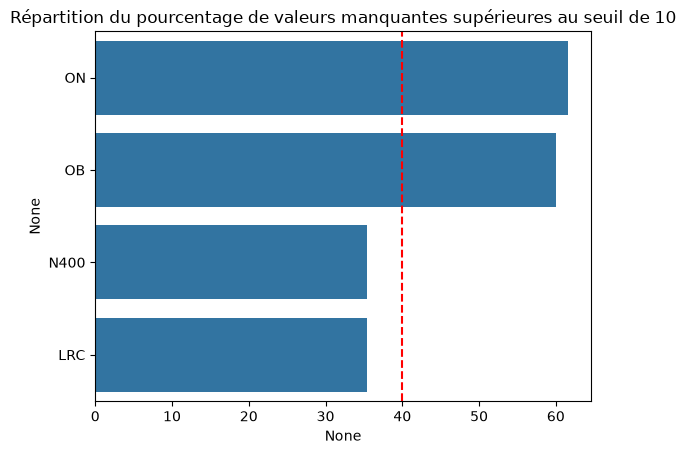

In [23]:
threshold_view = 10

filtered = percent_missing[percent_missing.values > threshold_view]
ax = sns.barplot(x = filtered, y = filtered.index, orient='h') 
ax.set_title(f"Répartition du pourcentage de valeurs manquantes supérieures au seuil de {threshold_view}");

threshold = 40

ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")

In [24]:
columns_to_drop = percent_missing[
    percent_missing.values > threshold].index
columns_to_drop

Index(['ON', 'OB'], dtype='str')

In [25]:
raw_df.drop(columns=columns_to_drop, inplace=True, errors="ignore")
raw_df.shape

(65, 16)

## Imputation valeurs manquantes

In [26]:
numeric_features = raw_df.select_dtypes(include=['float','int'])
numeric_features.shape

(65, 14)

In [27]:
from sklearn.impute import KNNImputer
imputation = KNNImputer(missing_values=np.nan)
imputed = imputation.fit_transform(numeric_features)
imputed = pd.DataFrame(imputed, columns=numeric_features.columns, index=raw_df.index)
imputed.shape

(65, 14)

In [28]:
raw_df.loc[:,numeric_features.columns] = imputed
numeric_features.columns

Index(['P300', 'P600', 'LNC', 'N400', 'LRC', 'IQ', 'VCI', 'PRI', 'WMI', 'SPI',
       'VBL', 'VSL', 'VBD', 'VSD'],
      dtype='str')

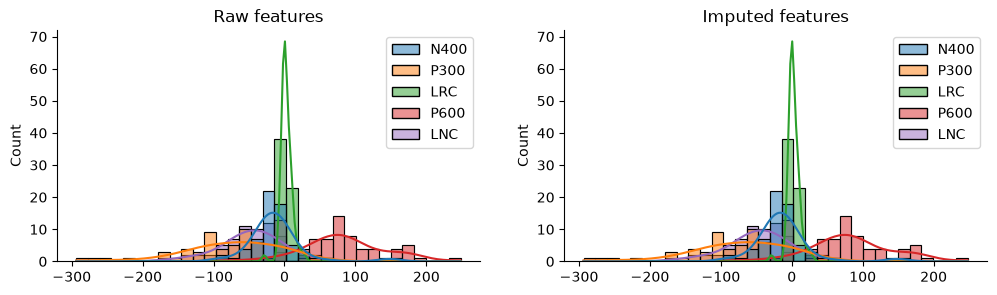

In [29]:
def compare_dist(features):
    fig, axes = plt.subplots(1,2,figsize=(12,3))
    ax=axes[0]
    sns.histplot(raw_df.loc[:,features],kde=True, ax=ax)
    ax.set_title(f"Raw features")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax=axes[1]
    sns.histplot(imputed.loc[:,features],kde=True, ax=ax)
    ax.set_title(f"Imputed features")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
compare_dist(["N400", "P300", "LRC", "P600", "LNC"])

## Outliers

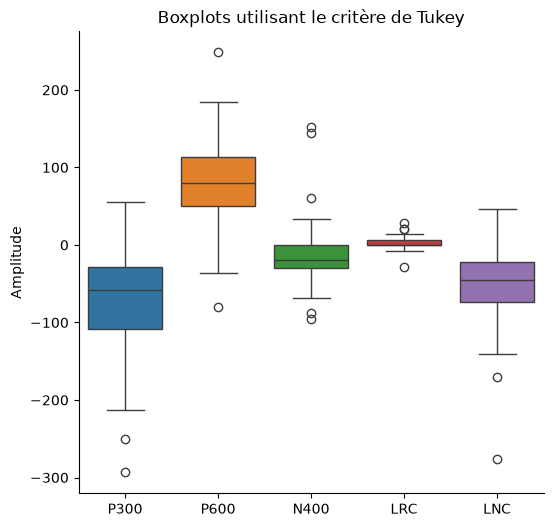

In [30]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(6,6))
sns.boxplot(data=raw_df.loc[:,["P300","P600", "N400", "LRC", "LNC"]], ax=ax)
ax.set_ylabel("Amplitude")
ax.set_title("Boxplots utilisant le critère de Tukey")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [31]:
imputed

,P300,P600,LNC,N400,LRC,IQ,VCI,PRI,WMI,SPI,VBL,VSL,VBD,VSD
0,-68.80,82.60,-54.10,-49.182,9.22,96.0,98.0,100.0,91.0,94.0,105.0,123.0,101.0,115.0
1,-44.70,80.00,-46.90,0.000,4.69,122.0,116.0,124.0,120.0,105.0,105.0,103.0,104.0,103.0
2,-108.10,96.40,-26.60,-50.700,-0.55,86.0,82.0,94.0,86.0,100.0,79.0,91.0,69.0,88.0
3,-35.30,0.00,0.00,23.700,-0.30,67.0,71.0,86.0,68.0,64.0,102.0,85.0,104.0,85.0
4,-38.70,42.14,0.00,8.880,-5.80,67.0,71.0,86.0,68.0,64.0,102.0,85.0,104.0,85.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,-40.02,69.74,-58.12,-11.600,7.20,115.0,124.0,106.0,114.0,102.0,114.0,106.0,119.0,106.0
61,0.00,50.70,-24.60,-16.040,-2.94,86.0,92.0,94.0,77.0,89.0,94.0,91.0,91.0,91.0
62,-55.80,55.90,-32.30,-13.420,1.10,71.0,81.0,84.0,74.0,64.0,97.0,109.0,93.0,109.0
63,-176.70,52.30,-35.50,-8.660,3.22,96.6,100.0,98.0,97.0,97.0,94.0,109.0,96.0,112.0


c:\Users\melan\DESU_DATA_2026\ProjetNR\.venv\Lib\site-packages\sklearn\kernel_approximation.py:1041: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
c:\Users\melan\DESU_DATA_2026\ProjetNR\.venv\Lib\site-packages\sklearn\kernel_approximation.py:1041: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
c:\Users\melan\DESU_DATA_2026\ProjetNR\.venv\Lib\site-packages\sklearn\kernel_approximation.py:1041: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
c:\Users\melan\DESU_DATA_2026\ProjetNR\.venv\Lib\site-packages\sklearn\kernel_approximation.py:1041: UserWarning: n_components > n_samples. This is not possible.
n_components was

                Méthode  Accord moyen avec consensus  \
0      Isolation Forest                        0.949   
1  Local Outlier Factor                        0.940   
2     Robust covariance                        0.934   
3   One-Class SVM (SGD)                        0.841   
4         One-Class SVM                        0.530   

   Fraction outliers détectés (moy)  Fraction outliers (écart-type)  \
0                             0.151                           0.006   
1                             0.151                           0.006   
2                             0.154                           0.007   
3                             0.069                           0.133   
4                             0.486                           0.086   

   Temps moyen (s)  Paires échouées  
0           0.3409                0  
1           0.0052                0  
2           0.0724                0  
3           0.0151                0  
4           0.0026                0  


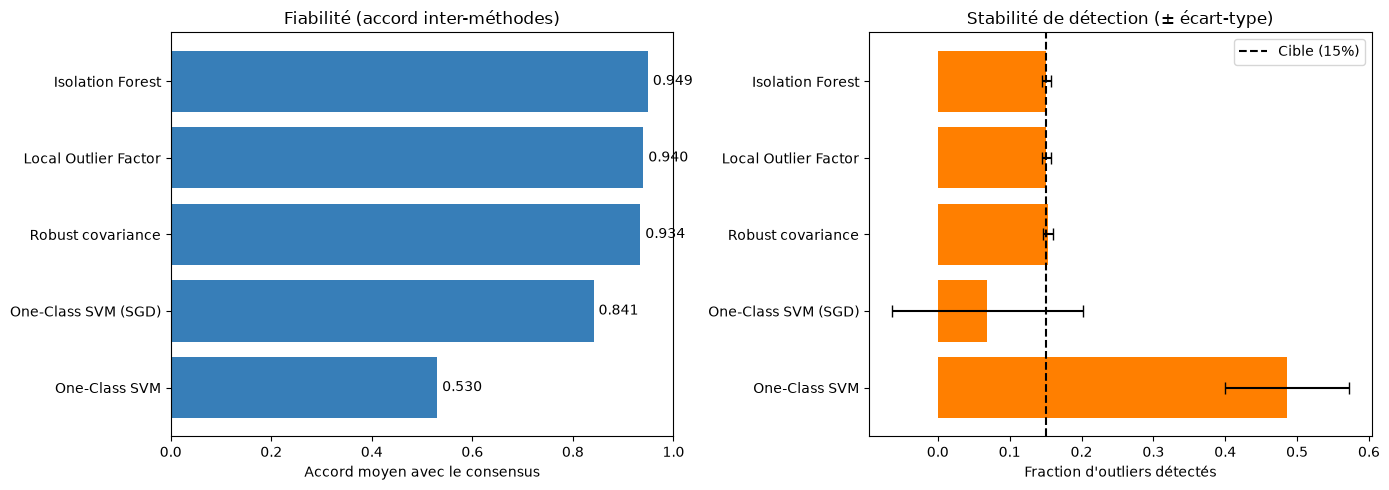

In [32]:
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import SGDOneClassSVM
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# --- Colonnes à tester (toutes sauf OB et ON, déjà supprimées) ---
columns = ["P300", "P600", "LNC", "N400", "LRC", "IQ",
           "VCI", "PRI", "WMI", "SPI", "VBL", "VSL", "VBD", "VSD"]

column_pairs = list(combinations(columns, 2))
outliers_fraction = 0.15

anomaly_algorithms = {
    "Robust covariance": lambda: EllipticEnvelope(contamination=outliers_fraction, random_state=42),
    "One-Class SVM": lambda: OneClassSVM(nu=outliers_fraction, kernel="rbf", gamma=0.1),
    "One-Class SVM (SGD)": lambda: make_pipeline(
        Nystroem(gamma=0.1, random_state=42, n_components=150),
        SGDOneClassSVM(nu=outliers_fraction, shuffle=True, fit_intercept=True,
                        random_state=42, tol=1e-6),
    ),
    "Isolation Forest": lambda: IsolationForest(contamination=outliers_fraction, random_state=42),
    "Local Outlier Factor": lambda: LocalOutlierFactor(n_neighbors=35, contamination=outliers_fraction),
}

# --- Stockage des résultats par paire ---
agreement_scores = {name: [] for name in anomaly_algorithms}
fraction_detected = {name: [] for name in anomaly_algorithms}
timings = {name: [] for name in anomaly_algorithms}
failed_pairs = {name: [] for name in anomaly_algorithms}

for col_x, col_y in column_pairs:
    X = imputed[[col_x, col_y]].to_numpy()

    # Sauter la paire si NaN restants
    if np.isnan(X).any():
        continue

    predictions = {}

    for name, make_algo in anomaly_algorithms.items():
        algo = make_algo()
        try:
            t0 = time.time()
            if name == "Local Outlier Factor":
                y_pred = algo.fit_predict(X)
            else:
                y_pred = algo.fit(X).predict(X)
            t1 = time.time()

            predictions[name] = y_pred
            timings[name].append(t1 - t0)
            fraction_detected[name].append(np.mean(y_pred == -1))
        except Exception:
            failed_pairs[name].append((col_x, col_y))
            predictions[name] = None

    # --- Calcul du consensus (vote majoritaire parmi les méthodes qui ont réussi) ---
    valid_preds = {k: v for k, v in predictions.items() if v is not None}
    if len(valid_preds) < 2:
        continue

    stacked = np.stack(list(valid_preds.values()))  # shape (n_methods, n_samples)
    # Consensus : -1 si la majorité des méthodes disent outlier
    consensus = np.sign(np.sum(stacked, axis=0))
    consensus[consensus == 0] = 1  # égalité -> inlier par défaut

    # --- Accord de chaque méthode avec le consensus ---
    for name, y_pred in valid_preds.items():
        agreement = np.mean(y_pred == consensus)
        agreement_scores[name].append(agreement)

# --- Construction du tableau récapitulatif ---
summary = []
for name in anomaly_algorithms:
    mean_agreement = np.mean(agreement_scores[name]) if agreement_scores[name] else np.nan
    mean_fraction = np.mean(fraction_detected[name]) if fraction_detected[name] else np.nan
    std_fraction = np.std(fraction_detected[name]) if fraction_detected[name] else np.nan
    mean_time = np.mean(timings[name]) if timings[name] else np.nan
    n_failed = len(failed_pairs[name])

    summary.append({
        "Méthode": name,
        "Accord moyen avec consensus": round(mean_agreement, 3),
        "Fraction outliers détectés (moy)": round(mean_fraction, 3),
        "Fraction outliers (écart-type)": round(std_fraction, 3),
        "Temps moyen (s)": round(mean_time, 4),
        "Paires échouées": n_failed,
    })

summary_df = pd.DataFrame(summary).sort_values(
    "Accord moyen avec consensus", ascending=False
).reset_index(drop=True)

print(summary_df)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphique 1 : Accord avec le consensus ---
axes[0].barh(
    summary_df["Méthode"],
    summary_df["Accord moyen avec consensus"],
    color="#377eb8"
)
axes[0].set_xlabel("Accord moyen avec le consensus")
axes[0].set_xlim(0, 1)
axes[0].set_title("Fiabilité (accord inter-méthodes)")
axes[0].invert_yaxis()  # meilleure méthode en haut
for i, v in enumerate(summary_df["Accord moyen avec consensus"]):
    axes[0].text(v + 0.01, i, f"{v:.3f}", va="center")

# --- Graphique 2 : Fraction d'outliers détectés avec barre d'erreur ---
axes[1].barh(
    summary_df["Méthode"],
    summary_df["Fraction outliers détectés (moy)"],
    xerr=summary_df["Fraction outliers (écart-type)"],
    color="#ff7f00",
    capsize=4
)
axes[1].axvline(outliers_fraction, color="black", linestyle="--", label="Cible (15%)")
axes[1].set_xlabel("Fraction d'outliers détectés")
axes[1].set_title("Stabilité de détection (± écart-type)")
axes[1].invert_yaxis()
axes[1].legend()

plt.tight_layout()
plt.show()

Donc on utilise le Isolation Forest

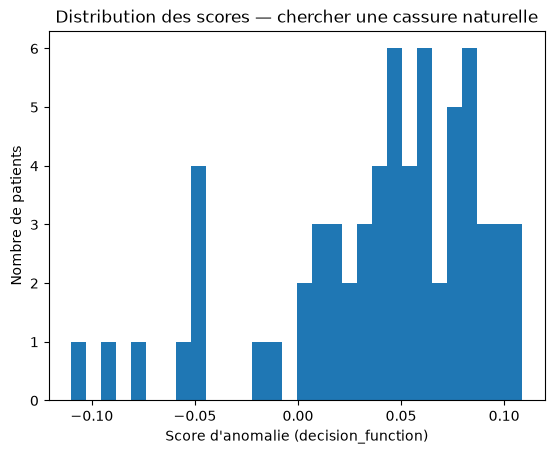

[-1.10027044e-01 -8.90944881e-02 -7.64478283e-02 -5.68029127e-02
 -5.13146426e-02 -5.00917418e-02 -4.91453262e-02 -4.62058110e-02
 -1.57903715e-02 -8.32295614e-03  3.47492325e-05  2.02577068e-04
  8.17889152e-03  1.01734155e-02  1.15078616e-02]


In [34]:
from sklearn.ensemble import IsolationForest
import numpy as np
import matplotlib.pyplot as plt

X = imputed[columns].to_numpy()  # toutes les variables numériques, ou une paire

clf = IsolationForest(random_state=42, contamination="auto")
clf.fit(X)
scores = clf.decision_function(X)  # plus c'est négatif, plus c'est anormal

plt.hist(scores, bins=30)
plt.xlabel("Score d'anomalie (decision_function)")
plt.ylabel("Nombre de patients")
plt.title("Distribution des scores — chercher une cassure naturelle")
plt.show()

print(np.sort(scores)[:15])  # regarder les 15 scores les plus bas

In [35]:
# Compter combien de patients sont sous le seuil de cassure observé
threshold = -0.02  # à ajuster précisément selon où tu vois le creux
n_outliers_visual = np.sum(scores < threshold)
contamination_estimated = n_outliers_visual / len(scores)

print(f"Nombre d'outliers estimé visuellement : {n_outliers_visual}")
print(f"Contamination estimée : {contamination_estimated:.3f}")

Nombre d'outliers estimé visuellement : 8
Contamination estimée : 0.123


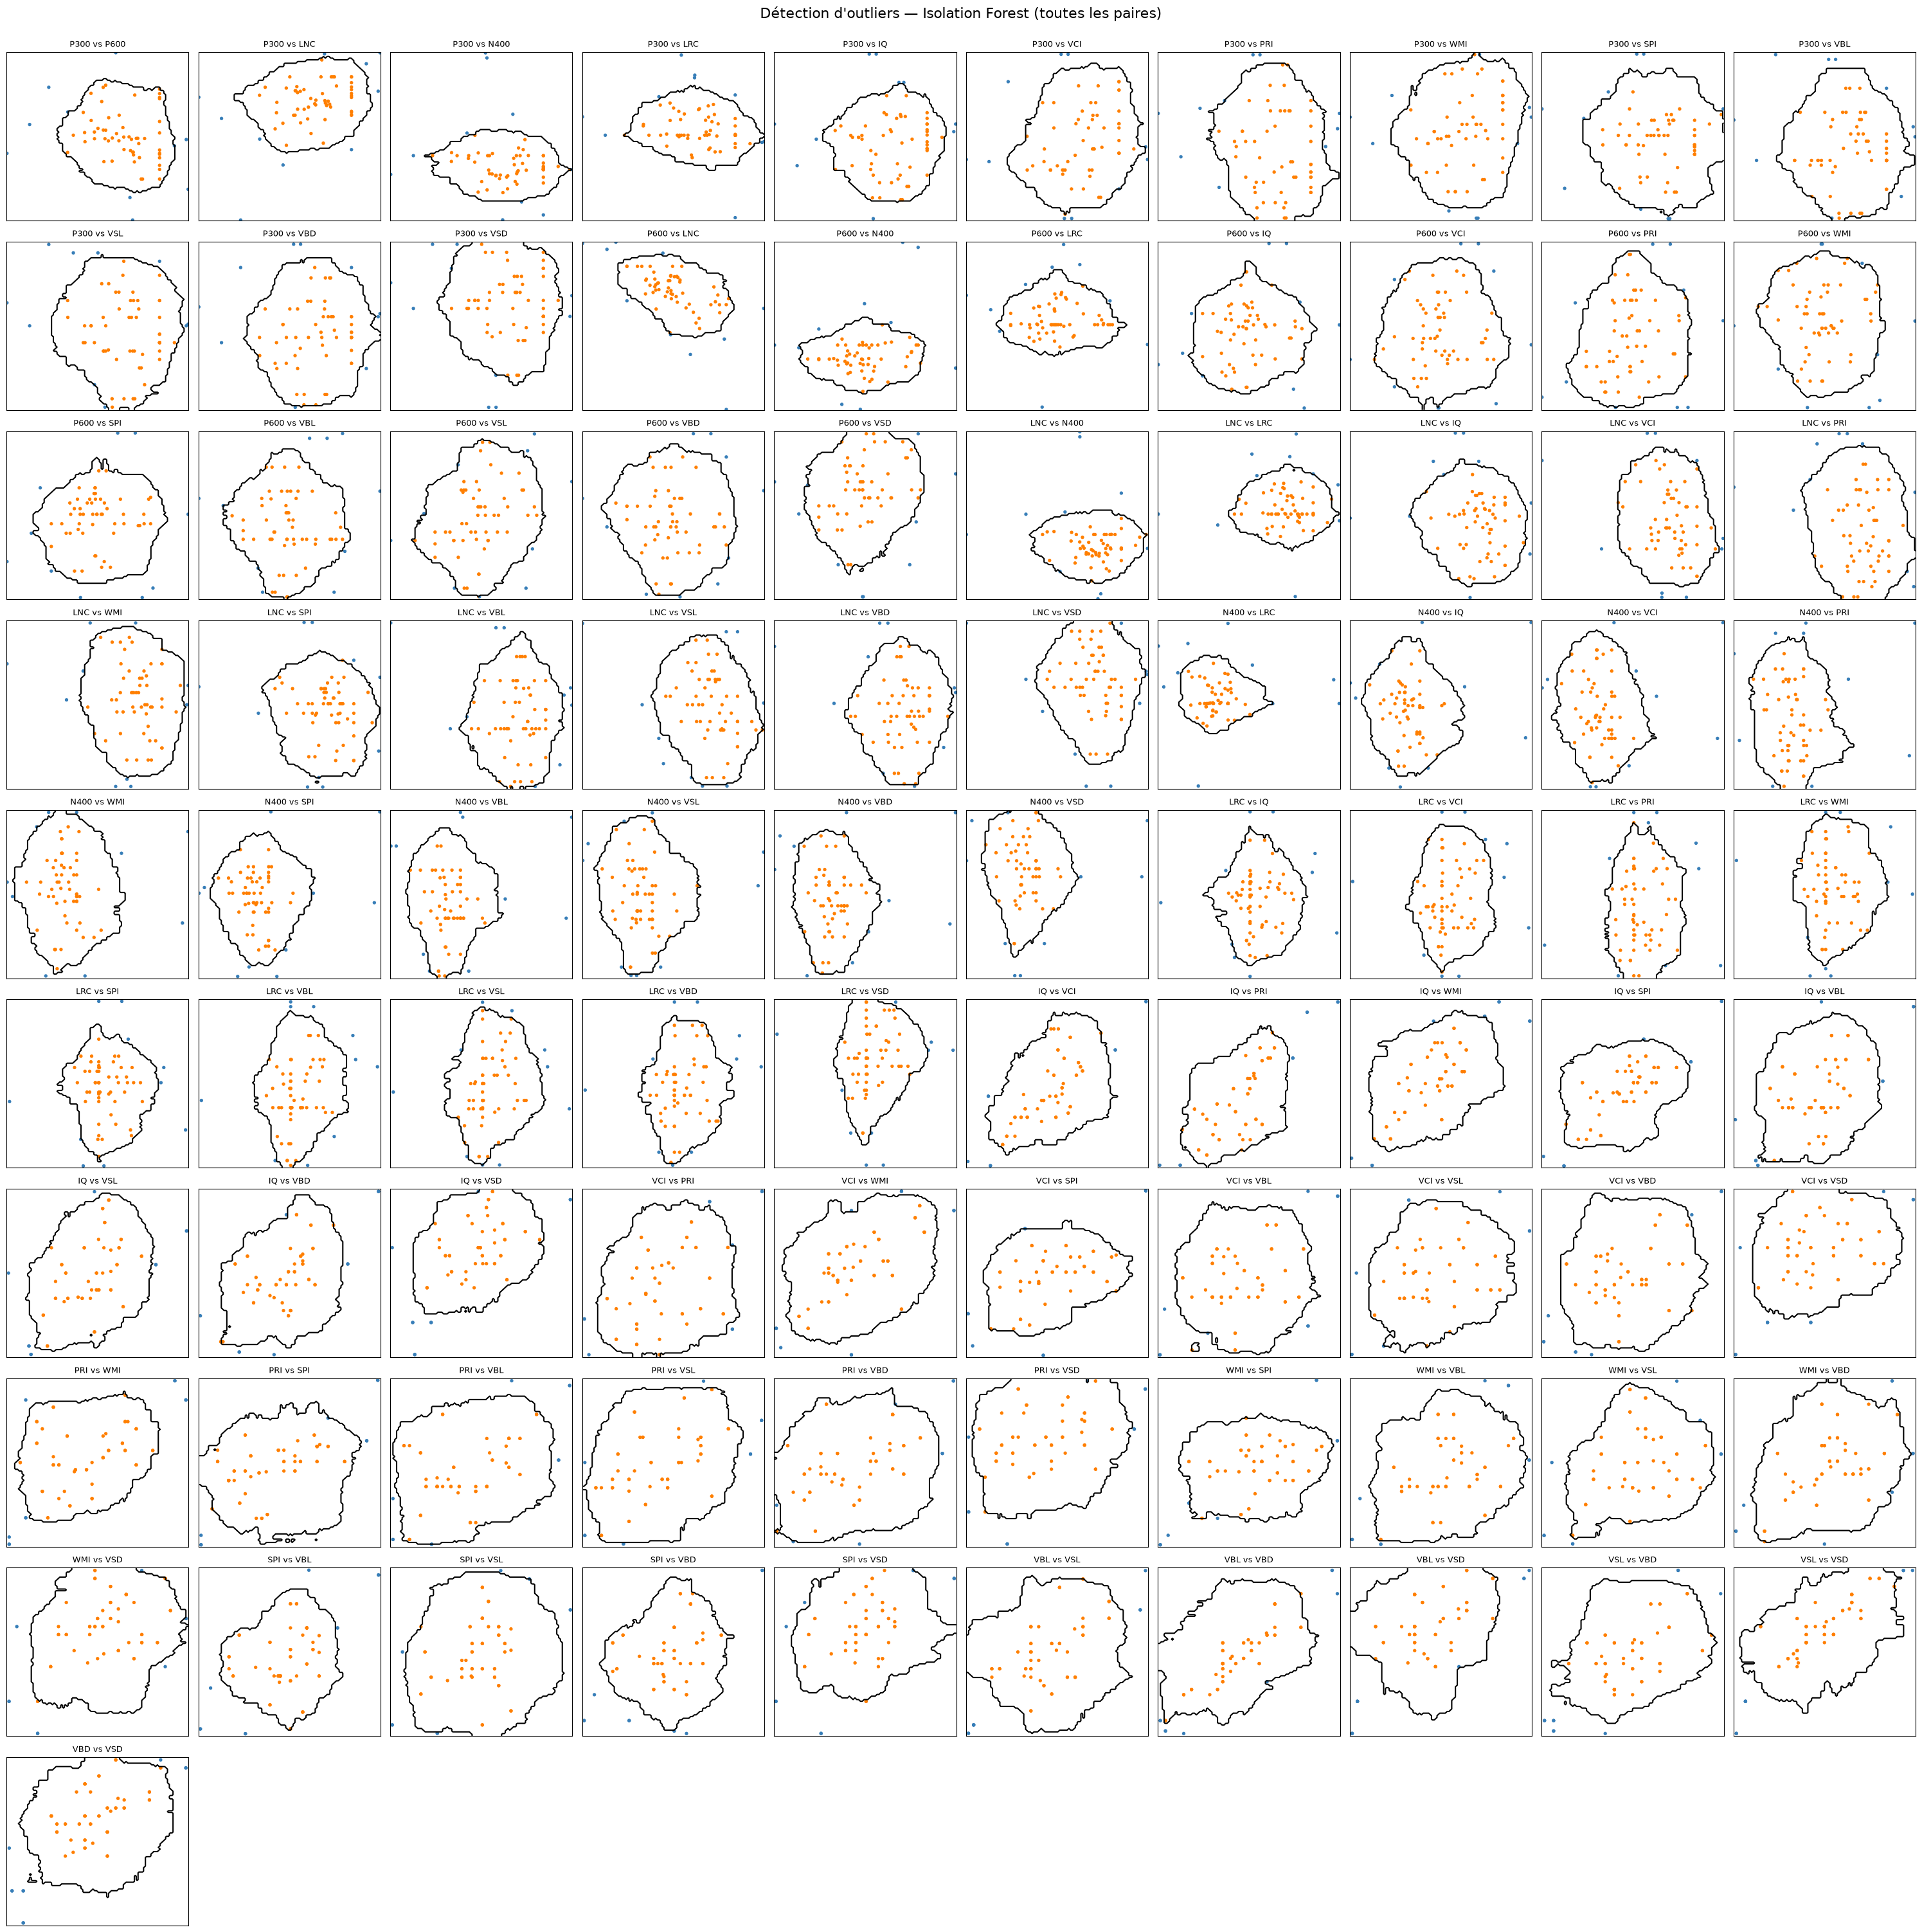

In [36]:
from sklearn.ensemble import IsolationForest

# --- Colonnes à tester (toutes sauf OB et ON) ---
columns = ["P300", "P600", "LNC", "N400", "LRC", "IQ",
           "VCI", "PRI", "WMI", "SPI", "VBL", "VSL", "VBD", "VSD"]

column_pairs = list(combinations(columns, 2))
n_pairs = len(column_pairs)

outliers_fraction = 0.15

# --- Disposition de la grille (aussi carrée que possible) ---
n_cols = int(np.ceil(np.sqrt(n_pairs)))
n_rows = int(np.ceil(n_pairs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
axes = axes.flatten()

colors = np.array(["#377eb8", "#ff7f00"])  # bleu = inlier, orange = outlier

for i, (col_x, col_y) in enumerate(column_pairs):
    ax = axes[i]

    X = imputed[[col_x, col_y]].to_numpy()

    # Sauter la paire si NaN restants
    if np.isnan(X).any():
        ax.set_title(f"{col_x} vs {col_y}\n(NaN, skip)", fontsize=8, color="red")
        ax.set_xticks(())
        ax.set_yticks(())
        continue

    clf = IsolationForest(contamination=outliers_fraction, random_state=42)
    y_pred = clf.fit_predict(X)

    # --- Frontière de décision ---
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contour(xx, yy, Z, levels=[0], linewidths=1.5, colors="black")
    ax.scatter(X[:, 0], X[:, 1], s=8, color=colors[(y_pred + 1) // 2])

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(f"{col_x} vs {col_y}", fontsize=9)
    ax.set_xticks(())
    ax.set_yticks(())

# --- Masquer les axes vides restants (si grille pas parfaitement remplie) ---
for j in range(n_pairs, len(axes)):
    axes[j].axis("off")

fig.suptitle("Détection d'outliers — Isolation Forest (toutes les paires)", fontsize=16, y=1.0)
plt.tight_layout()
plt.savefig("isolation_forest_all_pairs.png", dpi=150, bbox_inches="tight")
plt.show()